<a href="https://colab.research.google.com/github/Romanzilla/ML/blob/main/%D0%9B%D0%A02_2_%D0%9D%D0%B0%D0%B4%D1%96%D0%B9%D0%BA%D0%BE_3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Надійко, 3-10

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

1. Завантажити датасет

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


2. Визначити розмір датасета

In [3]:
df = pd.read_csv(os.path.join(path, "titanic.csv"))

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**About Dataset**

The dataset typically includes the following columns:

**PassengerId:** A unique identifier for each passenger.
Survived: This column indicates whether a passenger survived (1) or did not survive (0).

**Pclass (Ticket class):** A proxy for socio-economic status, with 1 being the highest class and 3 the lowest.

**Name:** The name of the passenger.

**Sex:** The gender of the passenger.

**Age:** The age of the passenger. (Note: There might be missing values in this column.)

**SibSp:** The number of siblings or spouses the passenger had aboard the Titanic.

**Parch:** текст жирним шрифтом The number of parents or children the passenger had aboard the Titanic.

**Ticket:** The ticket number.

**Fare:** The amount of money the passenger paid for the ticket.

The main goal of using this dataset is to predict whether a passenger survived or not based on various features. It serves as a popular introductory dataset for those learning data analysis, machine learning, and predictive modeling. Keep in mind that the dataset may be subject to variations and updates, so it's always a good idea to check the Kaggle website or dataset documentation for the most recent information.

3. Визначити тип даних.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


4.Визначити наявність пропущених значень. При наявності, замінити пропущені значення на медіану. Перевірити наявність дублікатів

In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df['Age'] = df['Age'].fillna(df['Age'].median(skipna=True))

# Видаляємо колонки
df.drop(['Cabin', 'Embarked'], axis=1, errors='ignore', inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

5. Ще раз перевірити наявність пропущених значень.

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


6. Сформувати датасет з обраними стовпцями: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

In [9]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


7. Змінили бінарні ознаки(Стать) на 0 і 1

In [10]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [11]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(f'Data types of the dataset:\n{df.dtypes}')

Data types of the dataset:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


/tmp/ipykernel_1017/275882515.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


8.Вивести описову статистику датасету describe()

In [12]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208
std,0.486592,0.836071,0.477990,13.019697,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


9.Ще раз перевірити кількість пропущених даних (впевнитись, що їх немає).

In [13]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


10.Вивести 5 перших рядків датасету.

In [14]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


11. Вивести 5 останніх рядків датасету.

In [15]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


12. Аналіз виживання залежно від статі: Обчисліть відсоток виживання для кожної статі. Чи була різниця у виживанні між чоловіками та жінками?

In [16]:
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100

print(f'Share of survived males: {survival_by_sex[0]:.2f}%')
print(f'Share of survived females: {survival_by_sex[1]:.2f}%')

Share of survived males: 18.89%
Share of survived females: 74.20%


In [17]:
print(f'Correlation between sex and survival: {df["Sex"].corr(df["Survived"])}')

Correlation between sex and survival: 0.5433513806577555


In [18]:
difference = abs(survival_by_sex[0] - survival_by_sex[1])

print(f'Difference in survival: {difference:.2f}%')

Difference in survival: 55.31%


Статистика порятунку демонструє чіткий гендерний дисбаланс, де показник виживання жінок (74,20%) перевищує чоловічий (18,89%) на 55,31%.


13. Обчисліть відсоток виживання для кожного класу (Pclass). Який клас мав найвищий рівень виживання (дати відповідь)?

In [19]:
class1_surv_rate = df[df['Pclass'] == 1]['Survived'].mean()
class2_surv_rate = df[df['Pclass'] == 2]['Survived'].mean()
class3_surv_rate = df[df['Pclass'] == 3]['Survived'].mean()

print(f'Виживання 1 класу: {class1_surv_rate * 100:.2f}%')
print(f'Виживання 2 класу: {class2_surv_rate * 100:.2f}%')
print(f'Виживання 3 класу: {class3_surv_rate * 100:.2f}%')

Виживання 1 класу: 62.96%
Виживання 2 класу: 47.28%
Виживання 3 класу: 24.24%


In [20]:
highest_class = df.groupby('Pclass')['Survived'].mean().idxmax()
print(f'Найвищий рівень виживання мав {highest_class} клас.')

Найвищий рівень виживання мав 1 клас.


Найвищий рівень виживання мав 1-й клас.

14. Визначте середній вік тих, хто вижив, і тих, хто не вижив. Чи впливає вік на виживання (дати відповідь)?

In [21]:
survived_mean_age = df[df['Survived'] == 1]['Age'].mean()

not_survived_mean_age = df[df['Survived'] == 0]['Age'].mean()

print(f'Середній вік тих, хто вижив: {survived_mean_age:.2f}')
print(f'Середній вік тих, хто не вижив: {not_survived_mean_age:.2f}')

Середній вік тих, хто вижив: 28.29
Середній вік тих, хто не вижив: 30.03


Показники середнього віку серед тих, хто вижив, і тих, хто загинув, є майже однаковими. Через це середнє значення не дозволяє оцінити реальний вплив віку на шанси вижити.

15. Розподіліть пасажирів на групи за рівнями тарифів (Fare) і обчисліть рівень виживання для кожної групи. Як тариф впливав на шанси виживання (дати відповідь)?

In [22]:
df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)

for i in range(6):
    surv_rate = df[(df['Fare_Category'] == i) & (df['Survived'] == 1)].shape[0] / df[df['Fare_Category'] == i].shape[0]

    print(f'Частка виживших пасажирів у групі {i}: {surv_rate * 100:.2f}%')

Частка виживших пасажирів у групі 0: 20.51%
Частка виживших пасажирів у групі 1: 19.08%
Частка виживших пасажирів у групі 2: 36.69%
Частка виживших пасажирів у групі 3: 43.62%
Частка виживших пасажирів у групі 4: 41.78%
Частка виживших пасажирів у групі 5: 69.80%


/tmp/ipykernel_1017/2709662386.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)


In [23]:
survived_fare = df[df['Survived'] == 1]['Fare'].mean()
not_survived_fare = df[df['Survived'] == 0]['Fare'].mean()

print(f'Середній тариф тих, хто вижив: {survived_fare:.2f}')
print(f'Середній тариф тих, хто не вижив: {not_survived_fare:.2f}')

Середній тариф тих, хто вижив: 48.40
Середній тариф тих, хто не вижив: 22.12


Рівень виживання пасажирів напряму залежав від вартості їхнього квитка.

16. Аналіз класу та тарифу: Визначте середній тариф (Fare) для кожного класу (Pclass). Чи існує значна різниця у тарифах між класами (дати відповідь)?

In [24]:
for i in range(1, 4):
    mean_fare = df[df['Pclass'] == i]['Fare'].mean()

    print(f'Середній тариф для {i} класу: {mean_fare:.2f}')

Середній тариф для 1 класу: 84.15
Середній тариф для 2 класу: 20.66
Середній тариф для 3 класу: 13.68


Ціни на квитки суттєво відрізнялися залежно від класу обслуговування. Пасажири першого класу в середньому купували найдорожчі квитки. Водночас для другого та третього класів тарифи були помітно нижчими, а найбюджетніший варіант поїздки пропонувався у третьому класі.

17. Як пов'язано середній вік пасажирів з виживанням? Відповідь дати аналітично чи графічно

In [25]:
survived_mean_age = df[df['Survived'] == 1]['Age'].mean()
not_survived_mean_age = df[df['Survived'] == 0]['Age'].mean()

print(f'Середній вік тих, хто вижив: {survived_mean_age:.2f}')
print(f'Середній вік тих, хто не вижив: {not_survived_mean_age:.2f}')

Середній вік тих, хто вижив: 28.29
Середній вік тих, хто не вижив: 30.03


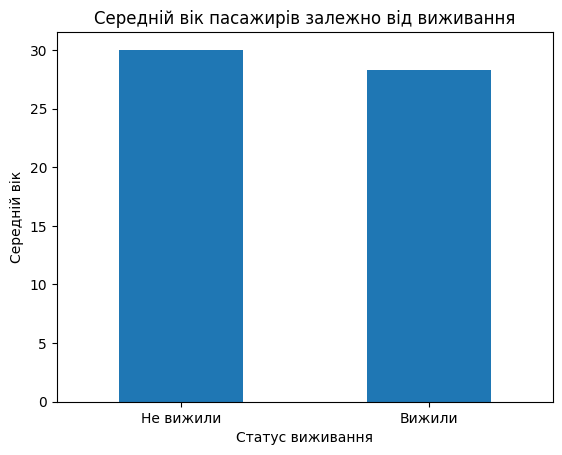

In [26]:
mean_age_survival = df.groupby('Survived')['Age'].mean()

mean_age_survival.index = ['Не вижили', 'Вижили']

mean_age_survival.plot(kind='bar')

plt.xlabel('Статус виживання')
plt.ylabel('Середній вік')
plt.title('Середній вік пасажирів залежно від виживання')
plt.xticks(rotation=0)
plt.show()

Мінімальна різниця у показниках свідчить про те, що вік пасажирів практично не вплинув на їхнє виживання.

In [27]:
# Clalculate survival rate per class per sex
for i in range(1, 4):
    for j in range(2):
        surv_rate = df[(df['Pclass'] == i) & (df['Sex'] == j) & (df['Survived'] == 1)].shape[0] / df[(df['Pclass'] == i) & (df['Sex'] == j)].shape[0]
        print(f'Share of survived {"male" if j == 0 else "female"} passengers in class {i}: {surv_rate * 100:.2f}%')

Share of survived male passengers in class 1: 36.89%
Share of survived female passengers in class 1: 96.81%
Share of survived male passengers in class 2: 15.74%
Share of survived female passengers in class 2: 92.11%
Share of survived male passengers in class 3: 13.54%
Share of survived female passengers in class 3: 50.00%


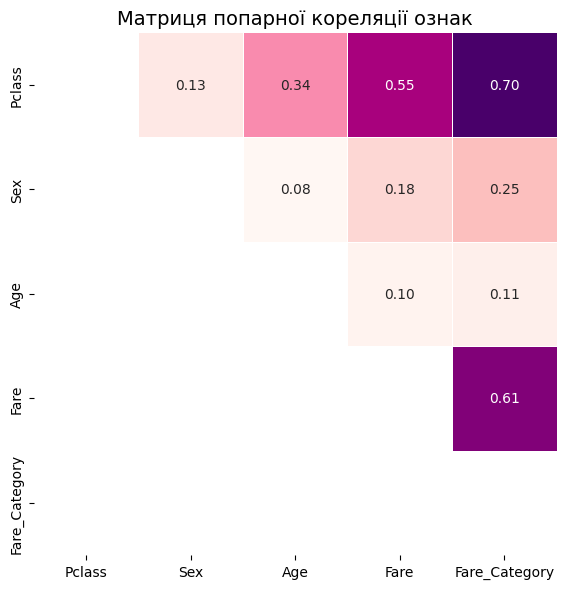

In [28]:
mtx = df.drop('Survived', axis=1).corr(numeric_only=True).abs()

# Побудова теплової карти кореляції
fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    mtx,
    cmap='RdPu',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    mask=np.tril(np.ones_like(mtx, dtype=bool)),
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

Найсильніший зв'язок виявлено між вартістю квитка (Fare) та класом каюти (Pclass), тоді як решта ознак майже не пов'язані між собою.